R1 - NOTA 6: Segmenta ou filtra os círculos maiores da imagem baseado em cores ou canais da imagem ou por exemplos com contornos e produz output visual. Exibe a área e o centro de massa da imagem.


ÁREA: 34516.0
ÁREA: 54316.0


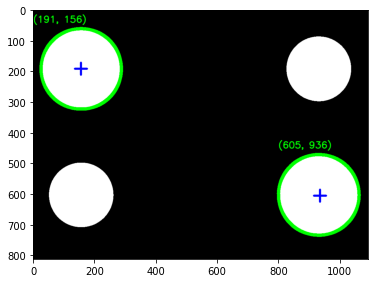

In [6]:
%matplotlib inline
import cv2
from matplotlib import pyplot as plt
import numpy as np

img = cv2.imread('circulos.png')

# FILTRO AZUL TURQUESA
image_lower_hsvBLUE1 = np.array([50, 130, 184])
image_upper_hsvBLUE1 = np.array([60, 205, 255])
image_lower_hsvBLUE2 = np.array([80, 130, 190])
image_upper_hsvBLUE2 = np.array([90, 210, 255])

# FILTRO VERMELHO
image_lower_hsvRED = np.array([0, 80, 37])
image_upper_hsvRED = np.array([10, 255, 255])
    
def escreve_texto(img, text, origem, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, str(text), origem, font,1,color,2,cv2.LINE_AA)
    
def desenha_cruz(img, cX,cY, size, color):
    cv2.line(img,(cX - size,cY),(cX + size,cY),color,5)
    cv2.line(img,(cX,cY - size),(cX, cY + size),color,5)    

def filtro_de_cor(img_bgr, low_hsv, high_hsv): 
    img = cv2.cvtColor(img_bgr,cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(img, low_hsv, high_hsv)
    return mask 

def mascara_or(mask1, mask2):
    mask = cv2.bitwise_or(mask1, mask2)
    return mask


mask_hsv_BLUE1 = filtro_de_cor(img, image_lower_hsvBLUE1, image_upper_hsvBLUE1)
mask_hsv_BLUE2 = filtro_de_cor(img, image_lower_hsvBLUE2, image_upper_hsvBLUE2)

mask1 = mascara_or(mask_hsv_BLUE1, mask_hsv_BLUE2)
mask2 = filtro_de_cor(img, image_lower_hsvRED, image_upper_hsvRED)
mask3 = mascara_or(mask1, mask2)

contornos, _ = cv2.findContours(mask3, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
mask_rgb = cv2.cvtColor(mask3, cv2.COLOR_GRAY2RGB) 
contornos_img = mask_rgb.copy()

maior = None
maior_area = 0
for c in contornos:
    area = cv2.contourArea(c)
    if area > maior_area:
        maior_area = area
        maior = c
        print("ÁREA:",area)
        
cv2.drawContours(contornos_img, [c], -1, [0, 255, 0], 10)
cv2.drawContours(contornos_img, [maior], -1, [0, 255, 0], 10)

M = cv2.moments(c)
M2 = cv2.moments(maior)

cX1 = int(M["m10"] / M["m00"])
cY1 = int(M["m01"] / M["m00"])

cX2 = int(M2["m10"] / M["m00"])
cY2 = int(M2["m01"] / M["m00"])
       
#faz a cruz no centro de massa
desenha_cruz(contornos_img, cX1,cY1, 20, (0,0,255))
desenha_cruz(contornos_img, cX2,cY2, 20, (0,0,255))
        
# Para escrever vamos definir uma fonte 
texto1 = cY1 , cX1
texto2 = cY2 , cX2
origem1 = (0,40)
origem2 = (800,450)
escreve_texto(contornos_img, texto1, origem1, (0,255,0))
escreve_texto(contornos_img, texto2, origem2, (0,255,0))


plt.figure(figsize=(6,8))
plt.imshow(contornos_img, cmap="Greys_r",vmin=0, vmax=255)

Faz o R1, Detecta o contorno dos círculos com a transformada de hough, traça uma reta entre os dois centros dos círculos e calcula o ângulo de inclinação da reta em relação o plano horizontal e exibe esse resultado.


O ângulo de inclinação da reta em relação o plano horizontal é: 0.4880826632114623


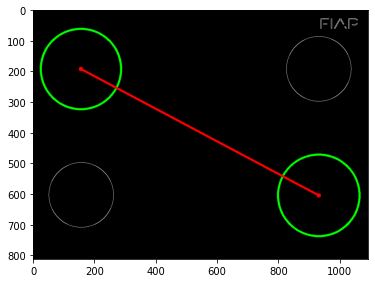

In [1]:
%matplotlib inline
import cv2
import math
from matplotlib import pyplot as plt
import numpy as np

img = cv2.imread('circulos.png', 0)
img = cv2.Canny(img,50,200)
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

circles = cv2.HoughCircles(img,cv2.HOUGH_GRADIENT,1,30,param1=50,param2=40,minRadius=114)
circles = np.uint16(np.around(circles))

if circles is not None:       
    for i in circles[0,:]:
        cv2.circle(cimg,(i[0],i[1]),i[2],(0,255,0),5)
        cv2.circle(cimg,(i[0],i[1]),2,(255,0,0),10)   

circle1x = circles[0][0][0]
circle2x = circles[0][1][0]

circle1y = circles[0][0][1]
circle2y = circles[0][1][1]

if circle1x > circle2x: 
    dx = circle1x - circle2x
else: 
    dx = circle2x - circle1x
    
if circle1y > circle2y: 
    dy = circle1y - circle2y
else: 
    dy = circle2y - circle1y

ang = math.atan2(dy, dx)

print("O ângulo de inclinação da reta em relação o plano horizontal é:",ang)

cv2.line(cimg,(circle1x,circle1y),(circle2x,circle2y),(255,0,0),5)
  
plt.figure(figsize = (6,8))   
plt.imshow(cimg, cmap="Greys_r",vmin=0, vmax=255)